In [84]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [47]:
df = pd.read_csv('../../../data/preprocess.csv')

In [48]:
df['release_date']= pd.to_datetime(
    df['release_date'], unit='s', errors='coerce'
)

In [49]:
df['controversy_score'] = df['positive_ratio'] * (1 - df['positive_ratio'])

df.sort_values('controversy_score', ascending=False)[
    ['name_store', 'main_genre', 'review_count', 'positive_ratio', 'controversy_score']
]

,name_store,main_genre,review_count,positive_ratio,controversy_score
43,The Drift Challenge,Racing,12.0,0.500000,0.250000
38,Ancient Cultivatrix,RPG,128.0,0.484375,0.249756
56,Raid Auctus,Casual,200.0,0.470000,0.249100
70,XiuzhenWorld,Action,200.0,0.540000,0.248400
34,Pathfinder: Gallowspire Survivors,Action,156.0,0.435897,0.245891
...,...,...,...,...,...
37,Gori: Cuddly Carnage,Action,200.0,0.990000,0.009900
3,MiSide,Adventure,200.0,1.000000,0.000000
19,DELTARUNE,RPG,200.0,1.000000,0.000000
48,VIVIDLOPE,Action,200.0,1.000000,0.000000


In [50]:
df2 = df.copy()

review_med = df2['total_reviews'].median()
pos_med = df2['positive_ratio'].median()

def classify_game(row):
    if row['total_reviews'] >= review_med and row['positive_ratio'] >= pos_med:
        return '대중성 높고 만족도 높음'
    elif row['total_reviews'] >= review_med and row['positive_ratio'] < pos_med:
        return '대중성 높지만 만족도 낮음'
    elif row['total_reviews'] < review_med and row['positive_ratio'] >= pos_med:
        return '대중성 낮지만 만족도 높음'
    else:
        return '대중성 낮고 만족도 낮음'

df2['success_type'] = df2.apply(classify_game, axis=1)

df2['success_type'].value_counts()

success_type
대중성 낮고 만족도 낮음     21
대중성 높고 만족도 높음     20
대중성 낮지만 만족도 높음    17
대중성 높지만 만족도 낮음    16
Name: count, dtype: int64

In [51]:
pd.crosstab(df2['main_genre'], df2['success_type'])

success_type,대중성 낮고 만족도 낮음,대중성 낮지만 만족도 높음,대중성 높고 만족도 높음,대중성 높지만 만족도 낮음
main_genre,,,,
Action,9,7,9,4
Adventure,2,7,4,7
Casual,4,1,6,3
Early Access,1,0,0,0
RPG,3,0,1,1
Racing,1,0,0,0
Simulation,1,1,0,0
Strategy,0,0,0,1


In [52]:
df2['value_score'] = df2['positive_ratio'] / np.log1p(df2['price_spy'])

value_games = df2.sort_values('value_score', ascending=False)

value_games[
    ['name_store', 'main_genre', 'price_spy', 'positive_ratio', 'value_score', 'total_reviews']
].head(15)

,name_store,main_genre,price_spy,positive_ratio,value_score,total_reviews
6,Yi Xian: The Cultivation Card Game,Casual,0,0.690000,inf,6132
50,Gravewood High,Action,0,0.666667,inf,1076
17,Eternal Return,Strategy,0,0.670000,inf,65046
33,风流公子romantic young man,Action,299,0.940000,0.164803,726
5,A Game About Digging A Hole™,Adventure,349,0.940000,0.160466,14229
29,Nodes Escape,NaN,199,0.820000,0.154766,490
64,A Shelter Full of Cats,Casual,499,0.950000,0.152866,660
61,Conbunn Cardboard,Adventure,699,0.980000,0.149594,438
9,Ages of Conflict: World War Simulator,Casual,699,0.960000,0.146541,4903
48,VIVIDLOPE,Action,999,1.000000,0.144765,388


In [53]:
df2['value_score'] = df2['positive_ratio'] / np.log1p(df2['price_spy'] + 1)

In [54]:
df2['value_score'].sort_values()

55    0.039967
23    0.062240
34    0.066524
15    0.071190
38    0.071195
        ...   
33    0.164707
50    0.961797
17    0.966606
6     0.995460
24         NaN
Name: value_score, Length: 74, dtype: float64

In [55]:
df2.groupby('main_genre')['value_score'].mean().sort_values(ascending=False)

main_genre
Strategy        0.966606
Casual          0.177155
Action          0.142037
Adventure       0.113699
Early Access    0.109938
RPG             0.108481
Simulation      0.097721
Racing          0.094281
Name: value_score, dtype: float64

In [56]:
genre_value = (
    df2.groupby('main_genre')
    .agg(
        game_count = ('name_store', 'count'),
        avg_value_score = ('value_score','mean'),
        median_value_score = ('value_score', 'median'),
        avg_positive_ratio = ('positive_ratio', 'mean'),
        avg_price=('price_spy', 'mean')
    ).sort_values('avg_value_score', ascending = False)
)
genre_value

,game_count,avg_value_score,median_value_score,avg_positive_ratio,avg_price
main_genre,,,,,
Strategy,1,0.966606,0.966606,0.670000,0.000000
Casual,14,0.177155,0.120228,0.781978,1073.785714
Action,29,0.142037,0.113651,0.792894,1472.344828
Adventure,20,0.113699,0.113783,0.794897,1401.500000
Early Access,1,0.109938,0.109938,0.770000,1099.000000
RPG,5,0.108481,0.115168,0.764875,1269.000000
Simulation,2,0.097721,0.097721,0.752222,2249.000000
Racing,1,0.094281,0.094281,0.500000,199.000000


In [57]:
def simplify_genre(g):
    if g in ['Action', 'Adventure', 'Casual']:
        return g
    else:
        return 'Other'

df2['genre_group'] = df2['main_genre'].apply(simplify_genre)

In [ ]:
# 교차표
ct = pd.crosstab(df2['main_genre'], df2['success_type'])
print(ct)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(ct)

print("\n[Chi-square 결과]")
print("chi2:", chi2)
print("p-value:", p)
print("dof:", dof)

# 기대도수도 같이 보기 (권장)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print("\n[Expected frequencies]")
print(expected_df.round(2))

success_type  대중성 낮고 만족도 낮음  대중성 낮지만 만족도 높음  대중성 높고 만족도 높음  대중성 높지만 만족도 낮음
main_genre                                                                
Action                    9               7              9               4
Adventure                 2               7              4               7
Casual                    4               1              6               3
Early Access              1               0              0               0
RPG                       3               0              1               1
Racing                    1               0              0               0
Simulation                1               1              0               0
Strategy                  0               0              0               1

[Chi-square 결과]
chi2: 23.15326941121276
p-value: 0.33586113009245183
dof: 21

[Expected frequencies]
success_type  대중성 낮고 만족도 낮음  대중성 낮지만 만족도 높음  대중성 높고 만족도 높음  대중성 높지만 만족도 낮음
main_genre                                                               

p ≥ 0.05
→ 관련 있다고 보기 어려움
장르와 성공유형은 서로 독립이다

In [60]:

n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.32515025968834893


계층이 나눠져 있는지표에서 장르별로 비교햤으면 어땠을까?
라지하이와 스몰하이에 있는 특정 장르의 차이를 비교해서 분석해보면 어떨까?



In [68]:
strata_summary = (
    df2.groupby('stratum')
    .agg(
        game_count=('appid', 'count'),
        avg_positive_ratio=('positive_ratio', 'mean'),
        avg_review_count=('review_count', 'mean'),
        avg_playtime=('avg_playtime', 'mean'),
        avg_review_length=('avg_review_length', 'mean'),
        main_genre=('main_genre', lambda x: x.mode()[0])
    )
)

print(strata_summary)

            game_count  avg_positive_ratio  avg_review_count  avg_playtime  \
stratum                                                                      
large_high          29            0.808571            197.50     81.986321   
mid_high            25            0.758455            175.68     19.775134   
small_high          20            0.776705            159.20     27.676383   

            avg_review_length main_genre  
stratum                                   
large_high         614.222680     Action  
mid_high           471.103100     Action  
small_high         369.945317     Action  


In [75]:
stratum_genre_perf = (
    df2.groupby(['stratum', 'main_genre'])
    .agg(
        game_count=('appid', 'count'),
        avg_positive_ratio=('positive_ratio', 'mean'),
        avg_review_count=('total_reviews', 'mean'),
        avg_playtime=('avg_playtime', 'mean')
    )
    .reset_index()
)

stratum_genre_perf

,stratum,main_genre,game_count,avg_positive_ratio,avg_review_count,avg_playtime
0,large_high,Action,12,0.811818,7982.583333,44.388725
1,large_high,Adventure,7,0.791429,22954.714286,41.211429
2,large_high,Casual,8,0.812500,26279.250000,106.514000
3,large_high,RPG,1,1.000000,2835.000000,46.600000
4,large_high,Strategy,1,0.670000,65046.000000,620.149000
5,mid_high,Action,9,0.794729,799.000000,15.568604
6,mid_high,Adventure,6,0.776667,2170.833333,13.548167
7,mid_high,Casual,2,0.750000,1099.000000,23.551500
8,mid_high,RPG,4,0.706094,811.500000,32.653531
9,mid_high,Racing,1,0.500000,538.000000,2.600000


In [76]:
best_by_positive = (
    stratum_genre_perf
    .sort_values(['stratum', 'avg_positive_ratio'], ascending=[True, False])
    .groupby('stratum')
    .head(1)
)

best_by_positive

,stratum,main_genre,game_count,avg_positive_ratio,avg_review_count,avg_playtime
3,large_high,RPG,1,1.000000,2835.000000,46.600000
5,mid_high,Action,9,0.794729,799.000000,15.568604
12,small_high,Adventure,7,0.813993,485.714286,13.836480


In [87]:
best_by_reviews = (
    stratum_genre_perf
    .sort_values(['stratum', 'avg_review_count'], ascending=[True, False])
    .groupby('stratum')
    .head(5)
)

best_by_reviews

,stratum,main_genre,game_count,avg_positive_ratio,avg_review_count,avg_playtime
4,large_high,Strategy,1,0.670000,65046.000000,620.149000
2,large_high,Casual,8,0.812500,26279.250000,106.514000
1,large_high,Adventure,7,0.791429,22954.714286,41.211429
0,large_high,Action,12,0.811818,7982.583333,44.388725
3,large_high,RPG,1,1.000000,2835.000000,46.600000
6,mid_high,Adventure,6,0.776667,2170.833333,13.548167
7,mid_high,Casual,2,0.750000,1099.000000,23.551500
8,mid_high,RPG,4,0.706094,811.500000,32.653531
5,mid_high,Action,9,0.794729,799.000000,15.568604
10,mid_high,Simulation,2,0.752222,619.000000,43.137889


In [86]:
best_by_playtime = (
    stratum_genre_perf
    .sort_values(['stratum', 'avg_playtime'], ascending=[True, False])
    .groupby('stratum')
    .head(5)
)

best_by_playtime

,stratum,main_genre,game_count,avg_positive_ratio,avg_review_count,avg_playtime
4,large_high,Strategy,1,0.670000,65046.000000,620.149000
2,large_high,Casual,8,0.812500,26279.250000,106.514000
3,large_high,RPG,1,1.000000,2835.000000,46.600000
0,large_high,Action,12,0.811818,7982.583333,44.388725
1,large_high,Adventure,7,0.791429,22954.714286,41.211429
10,mid_high,Simulation,2,0.752222,619.000000,43.137889
8,mid_high,RPG,4,0.706094,811.500000,32.653531
7,mid_high,Casual,2,0.750000,1099.000000,23.551500
5,mid_high,Action,9,0.794729,799.000000,15.568604
6,mid_high,Adventure,6,0.776667,2170.833333,13.548167


In [79]:
df2['norm_positive'] = df2['positive_ratio']
df2['norm_reviews'] = np.log1p(df2['total_reviews']) / np.log1p(df2['total_reviews']).max()
df2['norm_playtime'] = df2['avg_playtime'] / df2['avg_playtime'].max()

df2['performance_score'] = (
    df2['norm_positive'] * 0.5 +
    df2['norm_reviews'] * 0.3 +
    df2['norm_playtime'] * 0.2
)

In [80]:
df2['performance_score'] 

0     0.639157
1     0.703883
2     0.567011
3     0.801470
4     0.671146
        ...   
69    0.614236
70    0.489456
71    0.612956
72    0.591153
73    0.473907
Name: performance_score, Length: 74, dtype: float64

In [81]:
perf_summary = (
    df2.groupby(['stratum', 'main_genre'])
    .agg(
        game_count=('appid', 'count'),
        avg_perf=('performance_score', 'mean')
    )
    .reset_index()
)

perf_summary

,stratum,main_genre,game_count,avg_perf
0,large_high,Action,12,0.645043
1,large_high,Adventure,7,0.635196
2,large_high,Casual,8,0.671593
3,large_high,RPG,1,0.714750
4,large_high,Strategy,1,0.813420
5,mid_high,Action,9,0.568753
6,mid_high,Adventure,6,0.577703
7,mid_high,Casual,2,0.552453
8,mid_high,RPG,4,0.529066
9,mid_high,Racing,1,0.408847


In [82]:
best_genre = (
    perf_summary
    .sort_values(['stratum', 'avg_perf'], ascending=[True, False])
    .groupby('stratum')
    .head(1)
)

best_genre

,stratum,main_genre,game_count,avg_perf
4,large_high,Strategy,1,0.813420
6,mid_high,Adventure,6,0.577703
12,small_high,Adventure,7,0.566196


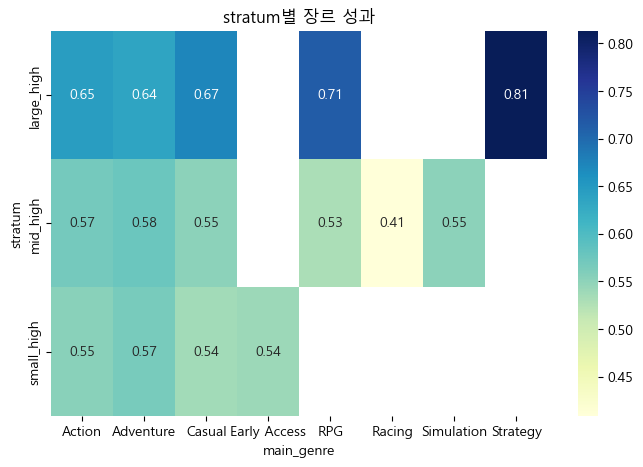

In [85]:
pivot = perf_summary.pivot(index='stratum', columns='main_genre', values='avg_perf')

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title('stratum별 장르 성과')
plt.show()